In [12]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
import shap
import matplotlib.pyplot as plt

In [2]:
territories_gdf = gpd.read_parquet('data/merged_data.parquet').to_crs(32636)
territories_gdf

,geometry,x,y,area,length,corners_count,outer_radius,inner_radius,aspect_ratio,residential,business,recreation,industrial,transport,special,agriculture,id
0,"POLYGON ((572511.69 6596566.888, 572396.077 65...",571890.770590,6.596896e+06,1.378104e+06,5038.253473,93,1027.674666,387.918839,2.088696,0.387353,0.000000,0.029147,0.092012,0.0,0.000000,0.0,0
1,"POLYGON ((571198.152 6596469.512, 571174.429 6...",571053.592580,6.596457e+06,1.210807e+03,469.652318,27,131.163697,4.881751,6.135552,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1
2,"POLYGON ((572867.931 6596649.534, 572806.268 6...",572753.824071,6.596626e+06,1.007658e+03,440.310836,21,128.091315,14.602166,6.145173,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,2
3,"POLYGON ((583241.896 6595452.983, 583366.911 6...",583400.357747,6.595371e+06,4.612804e+04,939.249125,19,182.364505,67.321517,1.997666,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,3
4,"POLYGON ((582403.742 6595460.48, 582445.687 65...",582416.423405,6.595452e+06,2.886984e+02,104.471470,10,27.715236,6.358547,2.087689,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30093,"POLYGON ((282882.262 6646551.855, 282870.234 6...",618450.818860,6.642078e+06,3.803840e+02,85.246434,9,21.834857,7.176879,2.149529,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,30093
30094,"POLYGON ((283260.086 6646763.048, 283264.203 6...",618764.184666,6.642262e+06,2.113179e+04,855.808176,20,209.111662,46.179469,3.654009,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,30094
30095,"POLYGON ((283218.856 6646746.21, 283023.775 66...",618675.714935,6.642287e+06,1.380902e+04,542.502261,6,111.965346,31.203913,2.781157,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,30095
30096,"POLYGON ((282918.205 6646642.759, 282890.041 6...",618529.762899,6.642217e+06,7.680389e+03,383.127822,9,82.713797,29.215515,2.576965,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,30096


In [3]:
territories_gdf = gpd.read_parquet('data/gnn_data/189_blocks.parquet')
territories_gdf

,geometry,x,y,area,length,corners_count,outer_radius,inner_radius,aspect_ratio,residential,business,recreation,industrial,transport,special,agriculture
0,"POLYGON ((518569.068 6630569.339, 518572.761 6...",518675.563312,6.630361e+06,4.578180e+04,1041.760746,27,242.643369,66.531611,2.523269,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
1,"POLYGON ((520471.821 6640303.719, 520313.433 6...",520080.584951,6.640538e+06,6.956898e+04,1548.965909,22,392.342288,68.731889,4.207522,0.832436,0.0,0.000000,0.0,0.0,0.0,0.000000
2,"POLYGON ((521378.872 6637710.776, 521384.025 6...",521355.759987,6.637613e+06,7.828425e+03,395.389021,12,91.708574,33.029894,2.320144,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
3,"POLYGON ((516547.574 6640756.825, 516563.074 6...",516415.423007,6.640535e+06,1.742783e+05,1819.476392,45,398.145822,169.080656,1.539850,0.150006,0.0,0.000000,0.0,0.0,0.0,0.000000
4,"POLYGON ((522534.991 6631934.329, 522519.952 6...",522294.908418,6.631824e+06,4.205989e+04,1102.734185,20,255.914972,46.037921,4.080549,0.368937,0.0,0.400537,0.0,0.0,0.0,0.000000
5,"POLYGON ((511522.325 6635247.401, 511591.381 6...",512410.355843,6.635024e+06,1.343598e+05,2779.029904,38,768.439498,62.136498,3.982567,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000
6,"POLYGON ((516153.41 6640369.331, 516105.966 66...",516055.911257,6.640523e+06,4.211490e+04,928.939341,20,216.190626,66.823850,3.078995,0.907471,0.0,0.000000,0.0,0.0,0.0,0.000000
7,"POLYGON ((513352.669 6647719.661, 513747.808 6...",517790.501596,6.637811e+06,4.268132e+08,261953.985412,440,18351.910308,6191.017360,1.336980,0.002229,0.0,0.140449,0.0,0.0,0.0,0.000605


In [4]:
# road_gdf = gpd.read_file('data/road.geojson').to_crs(32636)

In [5]:
road_buffer_gdf = gpd.read_parquet('data/road_buffer.parquet').to_crs(32636)
road_buffer_gdf

,geometry
0,"MULTIPOLYGON (((227443.293 6540592.627, 227443..."


In [ ]:
import geopandas as gpd
from shapely.ops import unary_union


# Применяем overlay (разница между территориями и буфером)
split_gdf = gpd.overlay(territories_gdf, road_buffer_gdf, how='difference')
split_gdf = split_gdf.explode(index_parts=False).reset_index(drop=True)
split_gdf['geometry'] = split_gdf.buffer(5).buffer(-5)





,x,y,area,length,corners_count,outer_radius,inner_radius,aspect_ratio,residential,business,recreation,industrial,transport,special,agriculture,geometry
0,518675.563312,6.630361e+06,4.578180e+04,1041.760746,27,242.643369,66.531611,2.523269,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,"POLYGON ((518563.986 6630560.176, 518564.049 6..."
1,520080.584951,6.640538e+06,6.956898e+04,1548.965909,22,392.342288,68.731889,4.207522,0.832436,0.0,0.000000,0.0,0.0,0.0,0.000000,"POLYGON ((519911.641 6640723.515, 519911.662 6..."
2,521355.759987,6.637613e+06,7.828425e+03,395.389021,12,91.708574,33.029894,2.320144,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,"POLYGON ((521318.915 6637631.711, 521318.93 66..."
3,516415.423007,6.640535e+06,1.742783e+05,1819.476392,45,398.145822,169.080656,1.539850,0.150006,0.0,0.000000,0.0,0.0,0.0,0.000000,"POLYGON ((516164.15 6640356.345, 516164.146 66..."
4,522294.908418,6.631824e+06,4.205989e+04,1102.734185,20,255.914972,46.037921,4.080549,0.368937,0.0,0.400537,0.0,0.0,0.0,0.000000,"POLYGON ((522057.583 6631773.259, 522057.688 6..."
5,512410.355843,6.635024e+06,1.343598e+05,2779.029904,38,768.439498,62.136498,3.982567,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,"POLYGON ((511497.535 6635205.3, 511497.596 663..."
6,516055.911257,6.640523e+06,4.211490e+04,928.939341,20,216.190626,66.823850,3.078995,0.907471,0.0,0.000000,0.0,0.0,0.0,0.000000,"POLYGON ((515919.482 6640696.783, 515919.566 6..."
7,517790.501596,6.637811e+06,4.268132e+08,261953.985412,440,18351.910308,6191.017360,1.336980,0.002229,0.0,0.140449,0.0,0.0,0.0,0.000605,"POLYGON ((507999.076 6639880.59, 507999.078 66..."
8,517790.501596,6.637811e+06,4.268132e+08,261953.985412,440,18351.910308,6191.017360,1.336980,0.002229,0.0,0.140449,0.0,0.0,0.0,0.000605,"POLYGON ((514270.365 6649246.789, 514270.411 6..."
9,517790.501596,6.637811e+06,4.268132e+08,261953.985412,440,18351.910308,6191.017360,1.336980,0.002229,0.0,0.140449,0.0,0.0,0.0,0.000605,"POLYGON ((516211.862 6650593.555, 516211.857 6..."


In [17]:
split_gdf = split_gdf.reset_index().rename(columns={'index': 'id'})

In [7]:
split_gdf.explore()

In [18]:
split_gdf

,id,x,y,area,length,corners_count,outer_radius,inner_radius,aspect_ratio,residential,business,recreation,industrial,transport,special,agriculture,geometry
0,0,518675.563312,6.630361e+06,4.578180e+04,1041.760746,27,242.643369,66.531611,2.523269,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,"POLYGON ((518563.986 6630560.176, 518564.049 6..."
1,1,520080.584951,6.640538e+06,6.956898e+04,1548.965909,22,392.342288,68.731889,4.207522,0.832436,0.0,0.000000,0.0,0.0,0.0,0.000000,"POLYGON ((519911.641 6640723.515, 519911.662 6..."
2,2,521355.759987,6.637613e+06,7.828425e+03,395.389021,12,91.708574,33.029894,2.320144,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,"POLYGON ((521318.915 6637631.711, 521318.93 66..."
3,3,516415.423007,6.640535e+06,1.742783e+05,1819.476392,45,398.145822,169.080656,1.539850,0.150006,0.0,0.000000,0.0,0.0,0.0,0.000000,"POLYGON ((516164.15 6640356.345, 516164.146 66..."
4,4,522294.908418,6.631824e+06,4.205989e+04,1102.734185,20,255.914972,46.037921,4.080549,0.368937,0.0,0.400537,0.0,0.0,0.0,0.000000,"POLYGON ((522057.583 6631773.259, 522057.688 6..."
5,5,512410.355843,6.635024e+06,1.343598e+05,2779.029904,38,768.439498,62.136498,3.982567,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,"POLYGON ((511497.535 6635205.3, 511497.596 663..."
6,6,516055.911257,6.640523e+06,4.211490e+04,928.939341,20,216.190626,66.823850,3.078995,0.907471,0.0,0.000000,0.0,0.0,0.0,0.000000,"POLYGON ((515919.482 6640696.783, 515919.566 6..."
7,7,517790.501596,6.637811e+06,4.268132e+08,261953.985412,440,18351.910308,6191.017360,1.336980,0.002229,0.0,0.140449,0.0,0.0,0.0,0.000605,"POLYGON ((507999.076 6639880.59, 507999.078 66..."
8,8,517790.501596,6.637811e+06,4.268132e+08,261953.985412,440,18351.910308,6191.017360,1.336980,0.002229,0.0,0.140449,0.0,0.0,0.0,0.000605,"POLYGON ((514270.365 6649246.789, 514270.411 6..."
9,9,517790.501596,6.637811e+06,4.268132e+08,261953.985412,440,18351.910308,6191.017360,1.336980,0.002229,0.0,0.140449,0.0,0.0,0.0,0.000605,"POLYGON ((516211.862 6650593.555, 516211.857 6..."


In [20]:
# 1. Создание и обучение модели
# Инициализация LabelEncoder с известными значениями LandUseType
le = LabelEncoder()
le.fit(['residential', 'recreation', 'special', 'industrial', 
        'agriculture', 'transport', 'business', 'basic', 
        'residential_individual', 'residential_lowrise', 
        'residential_midrise', 'residential_multistorey',
        'mixed_use'])  # Обучаем на строковых метках

# Генерация данных для обучения модели
np.random.seed(42)
n_samples = 10000
data = {
    'LandUseType': np.random.choice(['residential', 'recreation', 'special', 'industrial', 
                                     'agriculture', 'transport', 'business', 'basic', 
                                     'residential_individual', 'residential_lowrise', 'residential_midrise', 
                                     'residential_multistorey', 'mixed_use'], n_samples),

    'LocationScore': np.random.uniform(1, 10, n_samples),
    'AreaTotal': np.random.uniform(100, 20000, n_samples),
    'AreaResidential': np.random.uniform(0, 15000, n_samples),
    'AreaCommercial': np.random.uniform(0, 10000, n_samples),
    'Infrastructure': np.random.uniform(1, 10, n_samples),
    'RoadDevelopment': np.random.uniform(1, 10, n_samples),
    'EcoRestrictions': np.random.uniform(0, 5, n_samples),
    'PopulationDensity': np.random.uniform(50, 5000, n_samples),
    'AvgIncomeLevel': np.random.uniform(20000, 100000, n_samples),
    'DistanceToCenter': np.random.uniform(0.5, 20, n_samples),
    'MarketDemand': np.random.uniform(1, 10, n_samples),
    'Taxes': np.random.uniform(1000, 5000, n_samples),
    'Income': np.random.uniform(5000, 20000, n_samples),
    'ProvisionLevel': np.random.uniform(1, 10, n_samples)
}

land_use_effect = {
    'residential': 0.7,  # Жилая зона – средняя привлекательность, стабильный спрос
    'recreation': 0.4,  # Рекреационная зона – низкая доходность, но ценно для экологии и туризма
    'special': 0.3,  # Особого назначения – ограниченное использование, низкая инвестиционная привлекательность
    'industrial': 1.2,  # Промышленная зона – стабильный доход, но зависимость от экономики
    'agriculture': 0.5,  # Сельскохозяйственная зона – низкая доходность, но долгосрочные инвестиции
    'transport': 0.8,  # Транспортная зона – средняя привлекательность, но зависимость от инфраструктуры
    'business': 2.0,  # Общественно-деловая зона – высокая инвестиционная привлекательность
    'basic': 0.2,  # Базовая зона – малоперспективная для инвестиций
    'residential_individual': 0.9,  # ИЖС – средняя доходность, зависит от спроса
    'residential_lowrise': 1.0,  # Малоэтажная жилая зона – хороший баланс доходности и стабильности
    'residential_midrise': 1.2,  # Среднеэтажная жилая зона – выше привлекательность, плотность застройки
    'residential_multistorey': 1.5,  # Многоэтажная жилая зона – высокая инвестиционная привлекательность
    'mixed_use': 1.8  # Многофункциональная зона – высокая привлекательность за счет гибкости использования
}


# Формула доходности с учетом новых признаков
data['InvestmentReturn'] = (
    0.4 * data['LocationScore'] +
    0.3 * data['Infrastructure'] +
    0.2 * data['RoadDevelopment'] -
    0.2 * data['EcoRestrictions'] +
    0.1 * np.log(data['PopulationDensity']) +
    0.2 * data['AvgIncomeLevel'] / 10000 -
    0.3 * data['DistanceToCenter'] +
    0.3 * data['MarketDemand'] +
    0.3 * (data['AreaTotal'] / 10000) +
    0.2 * (data['AreaResidential'] / 10000) +
    0.4 * (data['AreaCommercial'] / 10000) -
    0.3 * (data['Taxes'] / 1000) +
    0.4 * (data['Income'] / 10000) +
    0.2 * data['ProvisionLevel'] +
    [land_use_effect[land] for land in data['LandUseType']] +
    np.random.normal(0, 0.5, n_samples)
)
df = pd.DataFrame(data)

# Подготовка данных для обучения
df['LandUseType'] = le.transform(df['LandUseType'])  # Кодируем строковые метки в числовые
X = df.drop('InvestmentReturn', axis=1)
y = df['InvestmentReturn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение модели
model = XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1, alpha=1.0, random_state=42)
model.fit(X_train, y_train)

# Оценка
print(f"Точность на обучающей выборке (R²): {model.score(X_train, y_train):.3f}")
print(f"Точность на тестовой выборке (R²): {model.score(X_test, y_test):.3f}")

Точность на обучающей выборке (R²): 0.862
Точность на тестовой выборке (R²): 0.837


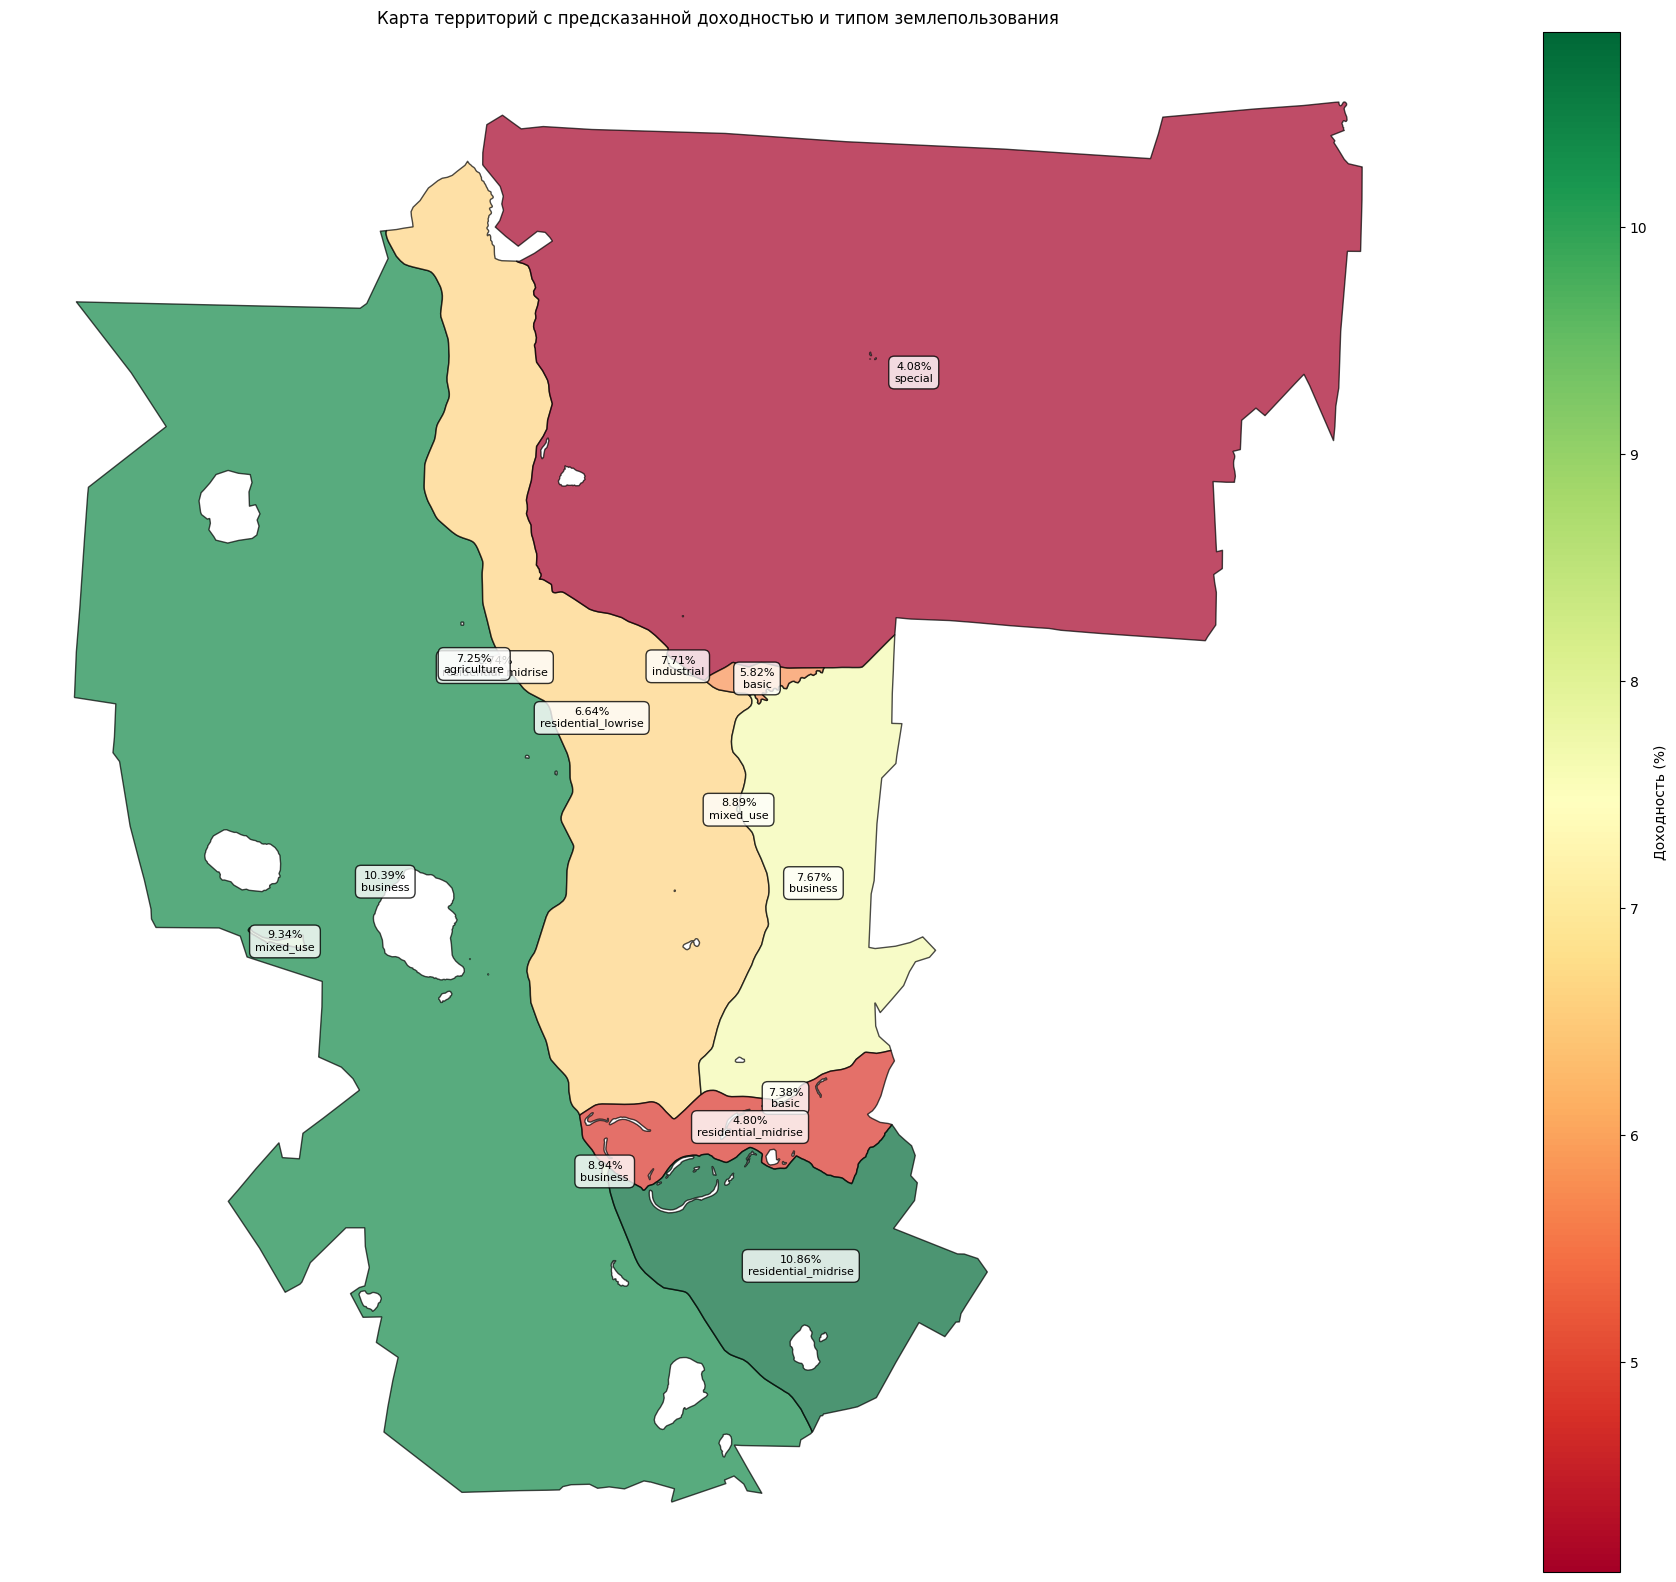

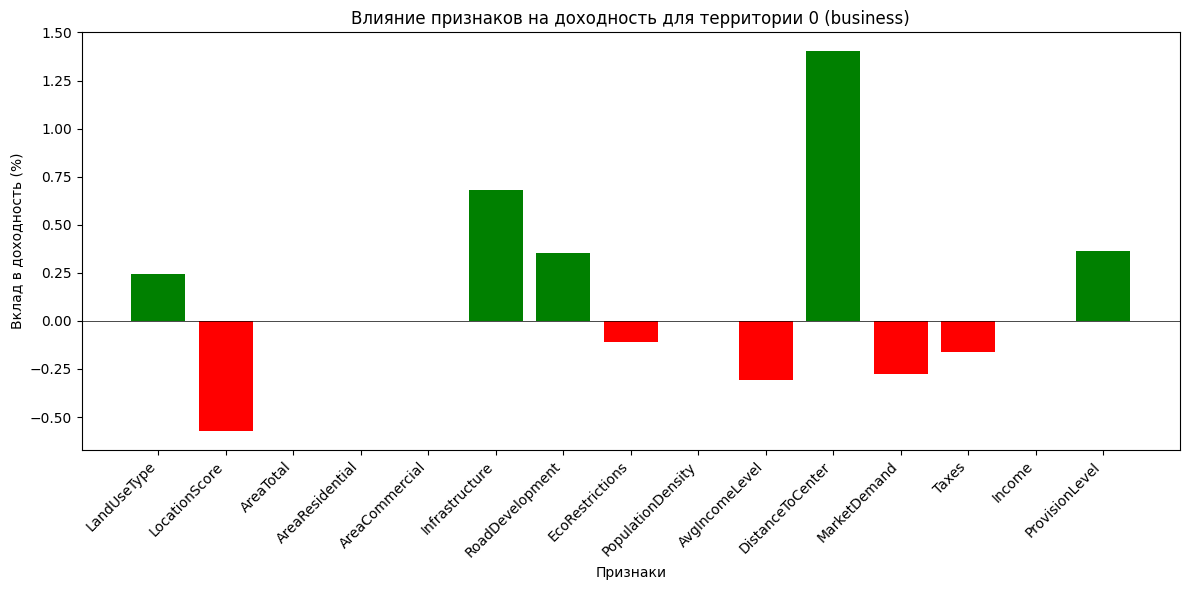

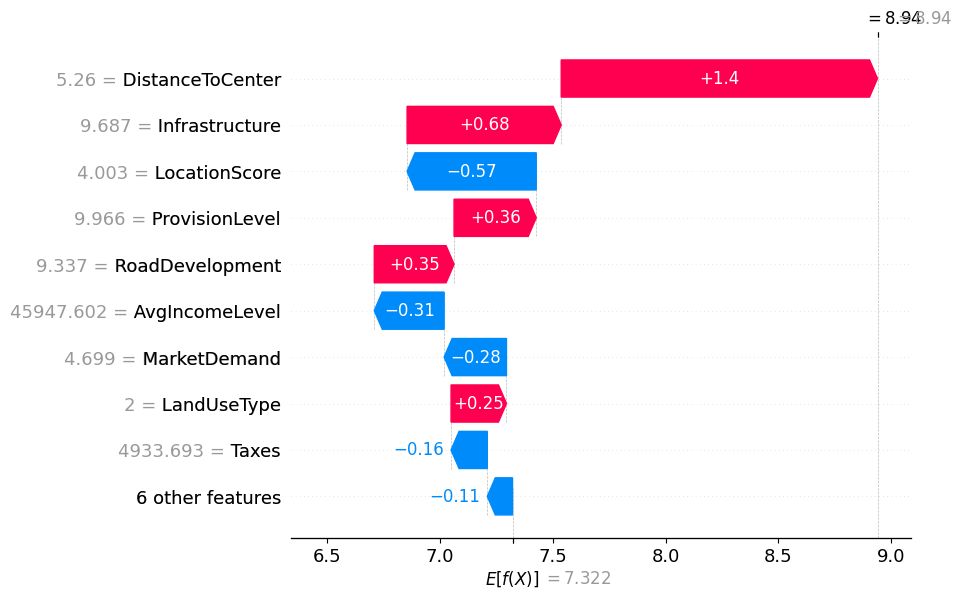


Вклад признаков в прогноз для новой территории:
LandUseType: 0.246
LocationScore: -0.573
AreaTotal: 0.000
AreaResidential: 0.000
AreaCommercial: 0.000
Infrastructure: 0.683
RoadDevelopment: 0.354
EcoRestrictions: -0.112
PopulationDensity: 0.000
AvgIncomeLevel: -0.310
DistanceToCenter: 1.402
MarketDemand: -0.276
Taxes: -0.161
Income: 0.000
ProvisionLevel: 0.364


In [22]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import shap
from shapely.geometry import Polygon

# Подготовка имеющегося GeoDataFrame
territory_gdf = split_gdf.copy()  # Копируем, чтобы избежать изменений в оригинале

# Добавляем необходимые атрибуты для модели (случайные данные для примера)
np.random.seed(42)  # Фиксируем генератор случайных чисел для воспроизводимости

territory_gdf['LandUseType'] = np.random.choice(['residential', 'recreation', 'special', 'industrial', 
        'agriculture', 'transport', 'business', 'basic', 
        'residential_individual', 'residential_lowrise', 
        'residential_midrise', 'residential_multistorey',
        'mixed_use'], len(territory_gdf))

territory_gdf['LocationScore'] = np.random.uniform(1, 10, len(territory_gdf))
territory_gdf['AreaTotal'] = np.random.uniform(100, 20000, len(territory_gdf))
territory_gdf['AreaResidential'] = np.random.uniform(0, 15000, len(territory_gdf))
territory_gdf['AreaCommercial'] = np.random.uniform(0, 10000, len(territory_gdf))
territory_gdf['Infrastructure'] = np.random.uniform(1, 10, len(territory_gdf))
territory_gdf['RoadDevelopment'] = np.random.uniform(1, 10, len(territory_gdf))
territory_gdf['EcoRestrictions'] = np.random.uniform(0, 5, len(territory_gdf))
territory_gdf['PopulationDensity'] = np.random.uniform(50, 5000, len(territory_gdf))
territory_gdf['AvgIncomeLevel'] = np.random.uniform(20000, 100000, len(territory_gdf))
territory_gdf['DistanceToCenter'] = np.random.uniform(0.5, 20, len(territory_gdf))
territory_gdf['MarketDemand'] = np.random.uniform(1, 10, len(territory_gdf))
territory_gdf['Taxes'] = np.random.uniform(1000, 5000, len(territory_gdf))
territory_gdf['Income'] = np.random.uniform(5000, 20000, len(territory_gdf))
territory_gdf['ProvisionLevel'] = np.random.uniform(1, 10, len(territory_gdf))

# Кодирование LandUseType для модели
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
territory_gdf['LandUseType'] = le.fit_transform(territory_gdf['LandUseType'])

feature_columns = ['LandUseType', 'LocationScore', 'AreaTotal', 'AreaResidential', 
                   'AreaCommercial', 'Infrastructure', 'RoadDevelopment', 
                   'EcoRestrictions', 'PopulationDensity', 'AvgIncomeLevel', 
                   'DistanceToCenter', 'MarketDemand', 'Taxes', 'Income', 'ProvisionLevel']

# Убираем ненужные столбцы
X_new = territory_gdf[feature_columns]
investment_returns = model.predict(X_new)

# Добавляем предсказания в GeoDataFrame
territory_gdf['InvestmentReturn'] = investment_returns


# Добавляем предсказания в GeoDataFrame
territory_gdf['InvestmentReturn'] = investment_returns

# Декодируем LandUseType обратно для визуализации
territory_gdf['LandUseType'] = le.inverse_transform(territory_gdf['LandUseType'])

# 🔹 Визуализация предсказаний на карте
fig, ax = plt.subplots(figsize=(30, 20))
territory_gdf.plot(column='InvestmentReturn', ax=ax, cmap='RdYlGn', legend=True, 
                    edgecolor='black', alpha=0.7, legend_kwds={'label': "Доходность (%)"})

plt.title("Карта территорий с предсказанной доходностью и типом землепользования")

# Аннотации
for idx, row in territory_gdf.iterrows():
    centroid = row['geometry'].centroid
    plt.annotate(f"{row['InvestmentReturn']:.2f}%\n{row['LandUseType']}", 
                 xy=centroid.coords[0], 
                 ha='center', va='center', fontsize=8, 
                 bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))

plt.axis('off')
plt.show()

# 🔹 SHAP-анализ для объяснения модели
explainer = shap.TreeExplainer(model)

# Анализ SHAP для первой территории
new_territory = X_new.iloc[[0]]  
shap_values_new = explainer.shap_values(new_territory.values)

# Бар-график SHAP
plt.figure(figsize=(12, 6))
plt.bar(new_territory.columns, shap_values_new[0], 
        color=['green' if x > 0 else 'red' for x in shap_values_new[0]])
plt.axhline(0, color='black', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Признаки")
plt.ylabel("Вклад в доходность (%)")
plt.title(f"Влияние признаков на доходность для территории 0 ({territory_gdf['LandUseType'].iloc[0]})")
plt.tight_layout()
plt.show()

shap.waterfall_plot(shap.Explanation(values=shap_values_new[0], 
                                     base_values=explainer.expected_value, 
                                     data=new_territory.iloc[0], 
                                     feature_names=new_territory.columns.tolist()))

# Вывод SHAP-вкладов
print("\nВклад признаков в прогноз для новой территории:")
for feature, shap_val in zip(new_territory.columns, shap_values_new[0]):
    print(f"{feature}: {shap_val:.3f}")


In [8]:
# mo_territories_gdf = gpd.read_parquet('data/gnn_data/territories.parquet')
# mo_territories_gdf

In [9]:
# block = gpd.read_parquet('data/gnn_data/189_blocks.parquet')
# block

In [10]:
# import geopandas as gpd
# import pandas as pd
# import os

# # Путь к файлам Parquet
# parquet_dir = "data/gnn_data"

# # Целевая CRS (можно заменить на нужную)
# target_crs = "EPSG:32636"

# # Создаем пустой список для хранения загруженных геоданных
# all_blocks = []

# # Проходим по всем territory_id
# for territory_id in mo_territories_gdf.index:
#     parquet_path = os.path.join(parquet_dir, f"{territory_id}_blocks.parquet")
    
#     # Проверяем, существует ли файл
#     if os.path.exists(parquet_path):
#         try:
#             block_gdf = gpd.read_parquet(parquet_path)
            
#             # Проверяем, есть ли у GeoDataFrame CRS, и приводим к целевой системе координат
#             if block_gdf.crs and block_gdf.crs != target_crs:
#                 block_gdf = block_gdf.to_crs(target_crs)

#             all_blocks.append(block_gdf)
#         except Exception as e:
#             print(f"Ошибка при загрузке {parquet_path}: {e}")
#     else:
#         print(f"Файл не найден: {parquet_path}")

# # Объединяем все загруженные файлы в один GeoDataFrame
# if all_blocks:
#     merged_gdf = gpd.GeoDataFrame(pd.concat(all_blocks, ignore_index=True), crs=target_crs)
#     print("Объединенный GeoDataFrame создан успешно!")
# else:
#     merged_gdf = gpd.GeoDataFrame()
#     print("Не удалось загрузить ни одного файла.")

# merged_gdf